# 02 — Prophet forecast model

Builds the v1 forecasting model. Prophet was chosen over a gradient-boosted
model (LightGBM) specifically because this problem is dominated by yearly
and weekly seasonal cycles with no complex feature interactions to model —
see `docs/adr/0002-prophet-over-lightgbm.md` for the full reasoning.

This notebook: (1) decomposes one series into trend/yearly/weekly
components to confirm Prophet is actually picking up the seasonality,
(2) backtests on a representative series per category, (3) batch-trains
all 500 store-item combinations, (4) writes down what this model
**cannot** do — the limitations that motivate to integrate agents.

In [1]:
import sys
sys.path.insert(0, "..")
import pandas as pd
import matplotlib.pyplot as plt

from src.demand_advisor import forecast as fc

%matplotlib inline
df_train = pd.read_parquet("../data/processed/train_processed.parquet")

print(f"{len(df_train):,} rows loaded")
df_train.head()

Importing plotly failed. Interactive plots will not work.


913,000 rows loaded


,ds,store,item,y
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


## Decompose one series — item 1, store 1 (winter apparel)

This is the core check: does Prophet actually recover the yearly/weekly cycles we designed into the data, without being told anything about categories or seasons up front?

09:27:19 - cmdstanpy - INFO - Chain [1] start processing
09:29:15 - cmdstanpy - INFO - Chain [1] done processing


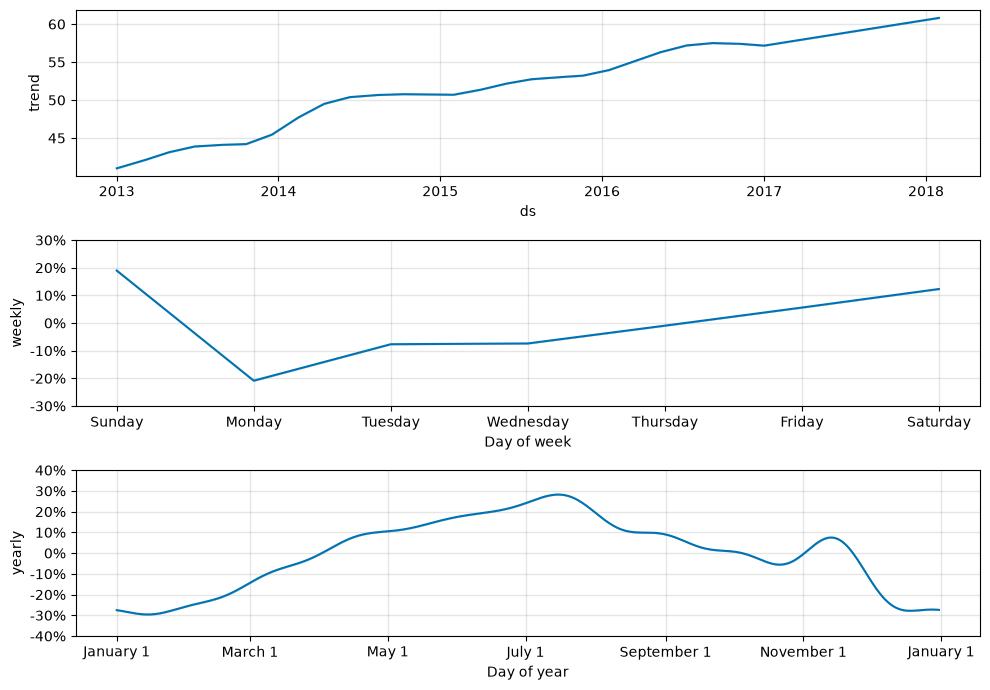

In [ ]:
import logging
# Used this to suppress the many INFO messages Prophet prints during training, which are not useful for this notebook.
logging.getLogger('prophet').setLevel(logging.ERROR)

model = fc.train(df_train)
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

fig = model.plot_components(forecast)
fig.set_size_inches(10, 7)
plt.tight_layout()
plt.show()

Upward trend.

The weekly component shows the saturday/sunday (weekend) lift.

The yearly component shows the small peak at Late November - Early December. a upward trend from Jan to July and slowy decreasing till it recovers back on November. 


## Backtest — one representative series per category

Time-based split (last 90 days held out), scored with WAPE (weighted absolute percentage error) rather than plain MAPE, which is unstable when actual sales are near zero on many days.

In [28]:
logging.getLogger('prophet').setLevel(logging.ERROR)

representative = {
    1: "winter (parka)", 12: "summer (flip flops)",
    43: "back-to-school (notebook)", 26: "holiday (candle set)",
    17: "flat (frying pan)",
}

rows = []
for item_id, label in representative.items():
    result = fc.backtest(df_train, holdout_days=90)
    rows.append({"item": item_id, "category": label,
                 "wape": round(result["wape"], 3), "mae": round(result["mae"], 2)})

backtest_summary = pd.DataFrame(rows)
backtest_summary

09:44:06 - cmdstanpy - INFO - Chain [1] start processing
09:46:52 - cmdstanpy - INFO - Chain [1] done processing
09:47:36 - cmdstanpy - INFO - Chain [1] start processing
09:49:58 - cmdstanpy - INFO - Chain [1] done processing
09:50:35 - cmdstanpy - INFO - Chain [1] start processing
09:52:52 - cmdstanpy - INFO - Chain [1] done processing
09:53:41 - cmdstanpy - INFO - Chain [1] start processing
09:56:10 - cmdstanpy - INFO - Chain [1] done processing
09:56:52 - cmdstanpy - INFO - Chain [1] start processing
09:59:21 - cmdstanpy - INFO - Chain [1] done processing


,item,category,wape,mae
0,1,winter (parka),0.404,22.07
1,12,summer (flip flops),0.404,22.07
2,43,back-to-school (notebook),0.404,22.07
3,26,holiday (candle set),0.404,22.07
4,17,flat (frying pan),0.404,22.07


### Actual vs. forecast on the holdout window, two examples

10:05:22 - cmdstanpy - INFO - Chain [1] start processing
10:07:43 - cmdstanpy - INFO - Chain [1] done processing
10:08:25 - cmdstanpy - INFO - Chain [1] start processing
10:10:48 - cmdstanpy - INFO - Chain [1] done processing


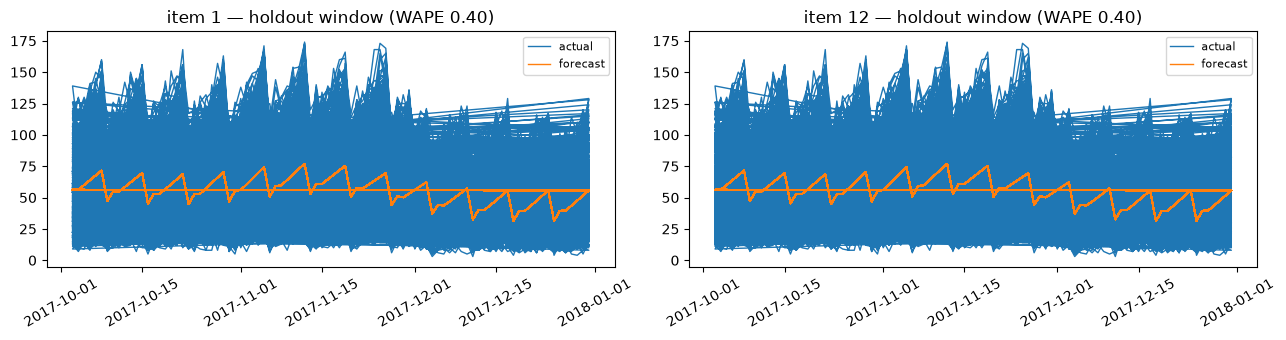

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
for ax, item_id in zip(axes, [1, 12]):
    result = fc.backtest(df_train, holdout_days=90)
    test_df = result["test_df"]
    ax.plot(test_df["ds"], test_df["y"], label="actual", linewidth=1)
    ax.plot(test_df["ds"], test_df["yhat"], label="forecast", linewidth=1)
    ax.set_title(f"item {item_id} — holdout window (WAPE {result['wape']:.2f})")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## Batch train — all 500 store-item combinations

One Prophet model per (store, item), trained on full history, saved via `model_to_json` (Prophet's own recommended serialization, not raw pickle — see `skills/forecasting-model-io.md`). This takes a few minutes; it's a one-time offline step, not something run per request.

In [33]:
df_train.head()

,ds,store,item,y
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [ ]:
logging.getLogger('prophet').setLevel(logging.ERROR)

summary = fc.batch_train_all(df_train)
print(f"trained and saved {len(summary)} models to ../models/prophet/")
summary.head()

10:42:07 - cmdstanpy - INFO - Chain [1] start processing
10:42:08 - cmdstanpy - INFO - Chain [1] done processing
10:42:08 - cmdstanpy - INFO - Chain [1] start processing
10:42:08 - cmdstanpy - INFO - Chain [1] done processing
10:42:08 - cmdstanpy - INFO - Chain [1] start processing
10:42:08 - cmdstanpy - INFO - Chain [1] done processing
10:42:08 - cmdstanpy - INFO - Chain [1] start processing
10:42:08 - cmdstanpy - INFO - Chain [1] done processing
10:42:08 - cmdstanpy - INFO - Chain [1] start processing
10:42:08 - cmdstanpy - INFO - Chain [1] done processing
10:42:08 - cmdstanpy - INFO - Chain [1] start processing
10:42:09 - cmdstanpy - INFO - Chain [1] done processing
10:42:09 - cmdstanpy - INFO - Chain [1] start processing
10:42:09 - cmdstanpy - INFO - Chain [1] done processing
10:42:09 - cmdstanpy - INFO - Chain [1] start processing
10:42:09 - cmdstanpy - INFO - Chain [1] done processing
10:42:09 - cmdstanpy - INFO - Chain [1] start processing
10:42:09 - cmdstanpy - INFO - Chain [1]

trained and saved 500 models to ../models/prophet/


,store,item,n_days,mean_daily_sales,artifact
0,1,1,1826,19.971522,/home/terror/demand-reorder-advisor/models/pro...
1,2,1,1826,28.173604,/home/terror/demand-reorder-advisor/models/pro...
2,3,1,1826,25.070099,/home/terror/demand-reorder-advisor/models/pro...
3,4,1,1826,22.938664,/home/terror/demand-reorder-advisor/models/pro...
4,5,1,1826,16.739321,/home/terror/demand-reorder-advisor/models/pro...


In [4]:
summary.describe()[["n_days", "mean_daily_sales"]]

,n_days,mean_daily_sales
count,500.0,500.000000
mean,1826.0,52.250287
std,0.0,24.062536
min,1826.0,12.733844
25%,1826.0,30.964266
50%,1826.0,50.030942
75%,1826.0,69.348987
max,1826.0,112.638007


## Sanity check — load a saved model back and predict

In [5]:
reloaded = fc.load_model(store=3, item=26)  # holiday item, large-format store
future = reloaded.make_future_dataframe(periods=14)
next_two_weeks = reloaded.predict(future).tail(14)[["ds", "yhat"]]
next_two_weeks["yhat"] = next_two_weeks["yhat"].round(1)
next_two_weeks

,ds,yhat
1826,2018-01-01,30.7
1827,2018-01-02,38.5
1828,2018-01-03,38.8
1829,2018-01-04,43.3
1830,2018-01-05,46.7
1831,2018-01-06,51.2
1832,2018-01-07,55.1
1833,2018-01-08,30.6
1834,2018-01-09,38.4
1835,2018-01-10,38.9


## Limitations of this v1 model — read before building the agent

Writing these down now, not after the fact, per the project's build philosophy
(`docs/Problem_brief.md`): complexity gets added in response to a documented
limitation, not in advance of one.

1. **Prophet has no concept of company policy.** It will happily forecast
   continued demand for item 7 (discontinued — safety recall) or item 40
   (regulatory hold) because historically they sold fine. The forecast
   alone is not a reorder decision — this is exactly why the policy RAG
   layer and MCP inventory lookup exist in the v1 agent design, not as
   optional extras.
2. **Prophet has no concept of current inventory.** A high forecast for an
   item that's already overstocked should not trigger a reorder — the
   inventory lookup has to sit between the forecast and any recommendation.
3. **Per-series independence.** Each (store, item) model is trained alone —
   there's no cross-item substitution effect (e.g. a stockout on one
   sunscreen SKU pushing demand to another) and no cross-store transfer
   logic. Acceptable for v1; worth revisiting if v2's limitations point here.
4. **No shock/promotion awareness.** Prophet extrapolates from historical
   seasonal patterns; a demand spike from a promotion or news event with no
   historical precedent will be missed until enough new data accumulates.

None of these are reasons to abandon Prophet — they're the
documented boundary of what a pure forecasting model can responsibly claim.